# YOLOv8 기반 제조 데이터 객체 탐지 실습
## 철강 표면 결함 탐지

NEU-DET 철강 이미지로 YOLOv8n을 학습하고, 결함의 종류와 위치를 얼마나 잘 찾는지 확인했다.
또한 confidence 기준을 바꾸면서 놓치는 결함과 잘못 찾는 결함이 어떻게 달라지는지 비교했다.

- 실행 환경: VS Code + Colab Tesla T4
- 학습 조건: YOLOv8n, 20 epochs, 입력 크기 320, batch 16
- 데이터: NEU-DET의 6가지 결함 유형

이 실험은 정답 박스가 있는 데이터를 이용한 지도학습 객체 탐지다.
정상 제품이나 처음 보는 결함을 구분하는 성능은 이번에 평가하지 않았다.


### 1. 실험 목표와 방법

YOLOv8으로 제조업의 결함 탐지를 할 수 있을지 궁금했다. 이번 실험에서는 모델의 confidence와
실제 정답을 비교해 보고, 어떤 결함을 잘 찾고 어떤 결함을 놓치는지 살펴보고자 했다.

확인할 내용은 두 가지다.

1. 20 epochs 학습한 YOLOv8n의 전체 성능과 클래스별 성능은 어느 정도인가?
2. confidence를 0.15, 0.25, 0.50으로 바꾸면 미검출(FN)과 오검출(FP)은 어떻게 달라지는가?

데이터는 학습·검증·시험용으로 약 70:15:15로 나누고 seed는 42로 고정했다.
파일명에 표시된 결함 유형별로 나누되, 한 이미지에 여러 결함이 있으면 모든 정답 박스를 사용했다.
검증 데이터에서 F2가 가장 높은 confidence를 고른 뒤 같은 기준으로 시험 데이터를 평가했다.
시험 결과를 보고 모델이나 confidence를 다시 선택하지는 않았다.

confidence는 모델이 예측에 부여한 점수다. 점수가 높아도 정답과 다를 수 있으므로
mAP, Precision, Recall과 함께 판단했다.


### 2. 실행 환경

VS Code의 노트북 커널을 Colab GPU로 선택한다. 데이터와 학습 결과는 Colab의 `/content` 아래에 저장한다.
다음 셀에서 GPU 연결을 확인하고 학습 조건과 라이브러리 버전을 기록한다.


In [38]:
import sys, subprocess, importlib.util
for module, package in [('ultralytics', 'ultralytics==8.4.172'), ('gdown', 'gdown==5.2.0')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
import os, json, time, random, hashlib, shutil, zipfile, platform
from pathlib import Path
from datetime import datetime, timezone
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch, ultralytics, yaml, gdown
from ultralytics import YOLO
from IPython.display import display, Markdown
assert torch.cuda.is_available(), 'Colab GPU 커널을 선택하세요. CPU에서는 자동 학습하지 않습니다.'
SEED, IMGSZ, EPOCHS, BATCH = 42, 320, 20, 16
random.seed(SEED); np.random.seed(SEED)
BASE = Path('/content/steel_defect_project')
RAW, DATA, ART = BASE/'raw', BASE/'dataset', BASE/'artifacts'
for folder in [RAW, DATA, ART]: folder.mkdir(parents=True, exist_ok=True)
NAMES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
env = {'python':sys.version, 'torch':torch.__version__, 'ultralytics':ultralytics.__version__,
       'gpu':torch.cuda.get_device_name(0), 'cuda':torch.version.cuda,
       'platform':platform.platform(), 'timestamp_utc':datetime.now(timezone.utc).isoformat(),
       'seed':SEED, 'imgsz':IMGSZ, 'epochs':EPOCHS, 'batch':BATCH}
(ART/'environment.json').write_text(json.dumps(env, indent=2, ensure_ascii=False))
print(json.dumps(env, indent=2, ensure_ascii=False))


{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "torch": "2.11.0+cu130",
  "ultralytics": "8.4.172",
  "gpu": "Tesla T4",
  "cuda": "13.0",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "timestamp_utc": "2026-10-04T07:34:50.182635+00:00",
  "seed": 42,
  "imgsz": 320,
  "epochs": 20,
  "batch": 16
}


### 3. 데이터 준비

NEU-DET는 6가지 철강 표면 결함을 담은 200×200 이미지 1,800장과 정답 박스로 구성되어 있다.
공식 제공자의 Google Drive에서 데이터를 내려받는다.

- [데이터 소개](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/)
- [NEU-DET 다운로드](https://drive.google.com/file/d/1qrdZlaDi272eA79b0uCwwqPrm2Q_WI3k/view)

자동 다운로드가 실패하면 같은 ZIP 파일을 Colab의 `/content/steel_defect_project/NEU-DET.zip`에
넣고 다시 실행한다.


In [39]:
archive = BASE/'NEU-DET.zip'
if not archive.exists() or not zipfile.is_zipfile(archive):
    gdown.download(id='1qrdZlaDi272eA79b0uCwwqPrm2Q_WI3k', output=str(archive), quiet=False)
assert zipfile.is_zipfile(archive), '유효한 NEU-DET.zip 파일을 준비한 뒤 다시 실행하세요.'
archive_hash = hashlib.sha256(archive.read_bytes()).hexdigest()
with zipfile.ZipFile(archive) as z:
    for member in z.infolist():
        dest = (RAW/member.filename).resolve()
        assert dest.is_relative_to(RAW.resolve()), '압축 파일 경로가 범위를 벗어납니다.'
    z.extractall(RAW)
(ART/'data_source.json').write_text(json.dumps({
    'provider':'Northeastern University, Kechen Song',
    'url':'https://drive.google.com/file/d/1qrdZlaDi272eA79b0uCwwqPrm2Q_WI3k/view',
    'archive_sha256':archive_hash}, indent=2))
print('ZIP MB:', round(archive.stat().st_size/1e6,2))
print('XML:', len(list(RAW.rglob('*.xml'))), 'Archive SHA256:', archive_hash)


ZIP MB: 27.61
XML: 1800 Archive SHA256: cf04bb0b05d364f23e05031b191b20b908a0e5eb11466df74ee7fba98ec835d5


### 4. 라벨 변환과 데이터 분할

XML에 저장된 박스 좌표를 YOLO 형식인 `클래스 중심_x 중심_y 너비 높이`로 변환한다.
중심 좌표와 너비·높이는 이미지 크기로 나누어 0~1 범위로 맞춘다.
XML 좌표는 1부터 시작하는 포함 구간으로 해석해 최소 좌표에서 1을 뺐다.
영상 밖으로 나간 좌표는 경계에 맞추고, 너비나 높이가 0 이하인 박스는 오류로 처리한다.

데이터를 확인하면서 다음 사항을 정리했다.

- `patches_101`, `patches_105`: 픽셀이 같은데 정답 박스가 달라 두 장을 제외했다.
- `crazing_120`, `inclusion_62`, `patches_198`: 같은 클래스·좌표의 박스가 두 번 들어 있어 하나씩 제거했다.
- 여러 종류의 결함이 함께 있는 이미지 123장: 파일명과 관계없이 XML에 있는 모든 결함을 사용했다.

같은 이미지를 찾을 때는 픽셀에서 계산한 SHA256 값을 비교했다. 같은 이미지가 학습과 시험 데이터에
동시에 들어가는 것도 확인했다. 이 방법은 픽셀이 완전히 같은 이미지만 찾으므로 비슷한 이미지까지
모두 제거한 것은 아니다.

정리한 1,798장을 파일명의 대표 결함 유형별로 약 70:15:15로 나눴다.
실제 분할은 학습 1,258장, 검증 269장, 시험 271장이다.

처음 학습할 때 중복 박스 3개는 Ultralytics에서 자동으로 제거됐다. 이후 직접 계산하는 평가에서도
같은 박스를 사용하도록 맞췄다. 유효한 학습 데이터는 같아서 기존 가중치를 그대로 사용해 평가했다.


In [40]:
images_by_stem = {}
for p in sorted(RAW.rglob('*')):
    if p.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']:
        images_by_stem.setdefault(p.stem, []).append(p)
raw_records, grouped_images, duplicate_boxes = [], {}, []
for xml_path in sorted(RAW.rglob('*.xml')):
    root = ET.parse(xml_path).getroot()
    candidates = images_by_stem.get(xml_path.stem, [])
    if not candidates:
        candidates = images_by_stem.get(Path(root.findtext('filename','')).stem, [])
    assert len(candidates)==1, f'이미지 대응 오류: {xml_path.name}, {candidates}'
    img_path = candidates[0]
    with Image.open(img_path) as im:
        im = im.convert('RGB'); w,h = im.size
        digest = hashlib.sha256(f'{w}x{h}:'.encode()+im.tobytes()).hexdigest()
    assert (w,h)==(int(root.findtext('size/width')),int(root.findtext('size/height'))), xml_path
    boxes=[]
    for obj in root.findall('object'):
        name=obj.findtext('name').strip()
        assert name in NAMES, f'알 수 없는 클래스 {name}'
        b=obj.find('bndbox')
        x1=max(0.,float(b.findtext('xmin'))-1); y1=max(0.,float(b.findtext('ymin'))-1)
        x2=min(float(w),float(b.findtext('xmax'))); y2=min(float(h),float(b.findtext('ymax')))
        assert x2>x1 and y2>y1, f'박스 좌표 오류 {xml_path.name}'
        boxes.append([NAMES.index(name),x1,y1,x2,y2])
    assert boxes, f'주석 없음: {xml_path.name}'
    # 같은 이미지 안의 동일 클래스·동일 좌표 박스는 정답 하나로 센다.
    unique_boxes = [list(b) for b in dict.fromkeys(tuple(b) for b in boxes)]
    if len(unique_boxes) != len(boxes):
        duplicate_boxes.append({'id': img_path.stem, 'removed': len(boxes)-len(unique_boxes)})
    boxes = unique_boxes
    classes=sorted(set(int(b[0]) for b in boxes))
    strata=[i for i,name in enumerate(NAMES) if img_path.stem.startswith(name+'_')]
    assert len(strata)==1, f'파일명 대표 유형을 판별할 수 없습니다: {img_path.name}'
    raw_records.append({'id':img_path.stem,'path':str(img_path),'width':w,'height':h,
                    'stratum_id':strata[0],'class_ids':classes,'hash':digest,'boxes':boxes})
for r in raw_records:
    grouped_images.setdefault(r['hash'],[]).append(r)
records, duplicate_count, annotation_conflicts = [], 0, []
for digest,group in grouped_images.items():
    signatures={tuple(sorted(tuple(b) for b in r['boxes'])) for r in group}
    if len(signatures)>1:
        annotation_conflicts.append({'hash':digest,'reason':'identical_pixels_conflicting_annotations',
                                     'images':[{'id':r['id'],'boxes':r['boxes']} for r in group]})
    else:
        records.append(group[0]); duplicate_count+=len(group)-1
audit={'raw_images':len(raw_records),'unique_pixel_groups':len(grouped_images),
       'identical_annotation_duplicates_removed':duplicate_count,
       'conflicting_groups':len(annotation_conflicts),
       'conflicting_images_excluded':sum(len(g['images']) for g in annotation_conflicts),
       'usable_images':len(records),'conflicts':annotation_conflicts,
       'duplicate_boxes_removed':sum(r['removed'] for r in duplicate_boxes),
       'duplicate_box_images':duplicate_boxes}
(ART/'annotation_audit.json').write_text(json.dumps(audit,ensure_ascii=False,indent=2))
display(pd.DataFrame([{k:v for k,v in audit.items() if k not in ['conflicts','duplicate_box_images']}]))
if annotation_conflicts:
    display(pd.DataFrame([{'reason':g['reason'],'images':', '.join(i['id'] for i in g['images'])} for g in annotation_conflicts]))
if duplicate_boxes:
    display(pd.DataFrame(duplicate_boxes))
assert len({r['id'] for r in records})==len(records), '파일 이름이 중복됩니다.'
assert len(records)>=1000, '예상보다 데이터가 적습니다. 다운로드 내용을 확인하세요.'
rng=random.Random(SEED)
for cls in range(len(NAMES)):
    group=sorted([r for r in records if r['stratum_id']==cls],key=lambda r:r['id'])
    rng.shuffle(group)
    n_train=int(len(group)*0.70); n_val=int(len(group)*0.15)
    for j,r in enumerate(group):
        r['split']='train' if j<n_train else ('val' if j<n_train+n_val else 'test')
# 데이터 구성이 바뀌면 별도 폴더에 저장해 이전 파일과 섞이지 않게 한다.
manifest_key=hashlib.sha256(json.dumps([(r['id'],r['hash'],r['boxes'],r['split']) for r in records],sort_keys=True).encode()).hexdigest()[:12]
DATA=BASE/'dataset'/('split_'+manifest_key)
for r in records:
    img_dir=DATA/'images'/r['split']; label_dir=DATA/'labels'/r['split']
    img_dir.mkdir(parents=True,exist_ok=True); label_dir.mkdir(parents=True,exist_ok=True)
    dest=img_dir/(r['id']+Path(r['path']).suffix.lower())
    shutil.copy2(r['path'],dest); r['yolo_image']=str(dest)
    lines=[]
    for cls,x1,y1,x2,y2 in r['boxes']:
        lines.append(f'{int(cls)} {(x1+x2)/2/r["width"]:.8f} {(y1+y2)/2/r["height"]:.8f} {(x2-x1)/r["width"]:.8f} {(y2-y1)/r["height"]:.8f}')
    (label_dir/(r['id']+'.txt')).write_text('\n'.join(lines)+'\n')
split_hashes={s:{r['hash'] for r in records if r['split']==s} for s in ['train','val','test']}
assert not (split_hashes['train'] & split_hashes['val'] or split_hashes['train'] & split_hashes['test'] or split_hashes['val'] & split_hashes['test'])
DATA_YAML=DATA/'data.yaml'
DATA_YAML.write_text(yaml.safe_dump({'path':str(DATA),'train':'images/train','val':'images/val',
                                   'test':'images/test','names':dict(enumerate(NAMES))},sort_keys=False))
(ART/'manifest.json').write_text(json.dumps(records,ensure_ascii=False,indent=2))
manifest=pd.DataFrame([{k:v for k,v in r.items() if k!='boxes'} | {'boxes':len(r['boxes'])} for r in records])
manifest.to_csv(ART/'split_manifest.csv',index=False)
print('Usable images:',len(records),'Identical-annotation duplicates removed:',duplicate_count)
print('Conflicting duplicate groups excluded:',len(annotation_conflicts))
print('Images with multiple defect classes:',sum(len(r['class_ids'])>1 for r in records))
display(pd.crosstab(manifest['stratum_id'].map(dict(enumerate(NAMES))),manifest['split']))
display(manifest.groupby('split').agg(images=('id','count'),boxes=('boxes','sum')))
box_counts=pd.DataFrame([{'class':NAMES[int(b[0])],'split':r['split']} for r in records for b in r['boxes']])
display(pd.crosstab(box_counts['class'],box_counts['split']))


,raw_images,unique_pixel_groups,identical_annotation_duplicates_removed,conflicting_groups,conflicting_images_excluded,usable_images,duplicate_boxes_removed
0,1800,1799,0,1,2,1798,3


,reason,images
0,identical_pixels_conflicting_annotations,"patches_101, patches_105"


,id,removed
0,crazing_120,1
1,inclusion_62,1
2,patches_198,1


Usable images: 1798 Identical-annotation duplicates removed: 0
Conflicting duplicate groups excluded: 1
Images with multiple defect classes: 123


split,test,train,val
stratum_id,,,
crazing,45,210,45
inclusion,45,210,45
patches,46,208,44
pitted_surface,45,210,45
rolled-in_scale,45,210,45
scratches,45,210,45


,images,boxes
split,,
test,271,621
train,1258,2894
val,269,665


split,test,train,val
class,,,
crazing,99,482,107
inclusion,151,688,171
patches,127,608,139
pitted_surface,66,301,65
rolled-in_scale,102,433,93
scratches,76,382,90


### 5. 데이터 확인

학습 데이터에서 결함 유형별 이미지 한 장씩을 골라 정답 박스를 표시했다.
이어서 박스의 개수와 이미지에서 차지하는 면적을 확인했다.

유형별 이미지 수는 비슷하지만 실제 박스 수와 크기는 달랐다.
inclusion에는 작은 박스가 많고 pitted_surface에는 이미지의 넓은 영역을 차지하는 박스가 있었다.
이 차이를 고려해 전체 성능뿐 아니라 클래스별 AP도 비교했다.


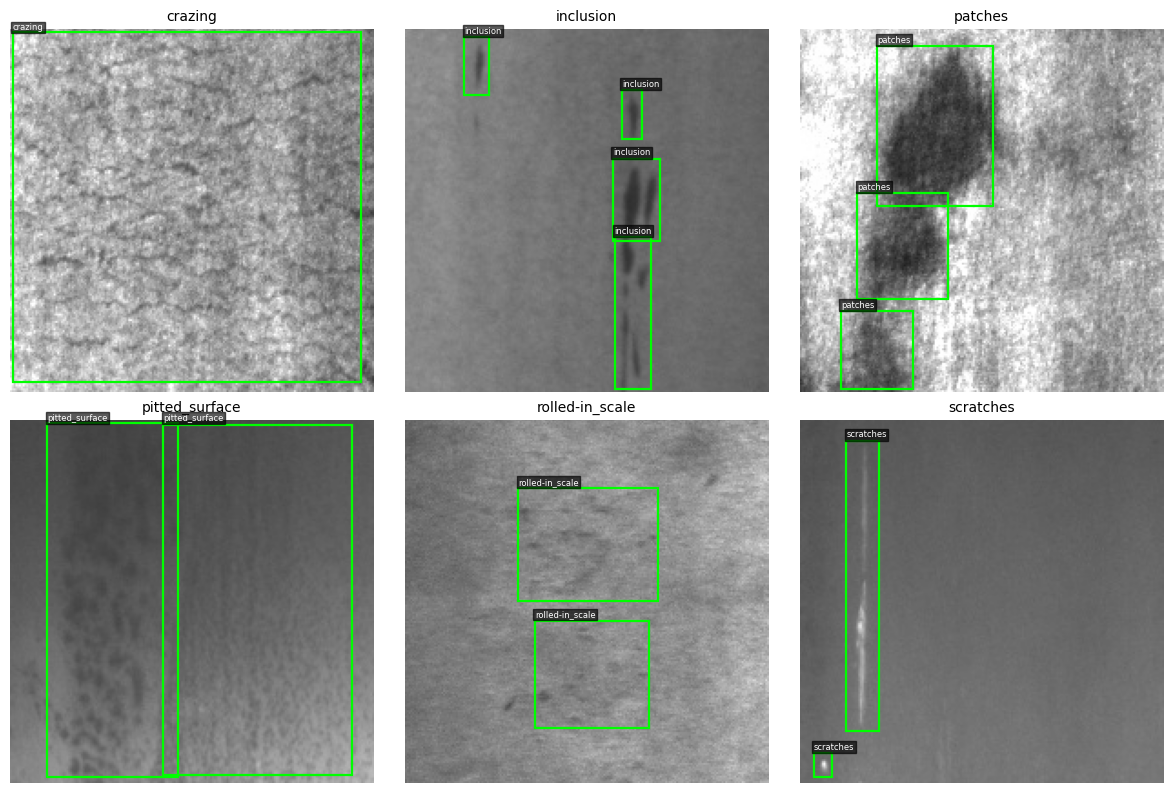

,boxes,median_area
class,,
crazing,482,0.215300
inclusion,688,0.043625
patches,608,0.097775
pitted_surface,301,0.565000
rolled-in_scale,433,0.127500
scratches,382,0.080275


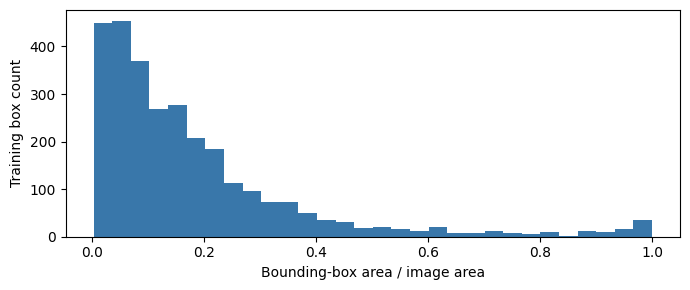

In [41]:
def draw_boxes(ax, path, boxes, title, color='lime', scores=None):
    ax.imshow(Image.open(path).convert('RGB'))
    for i,(cls,x1,y1,x2,y2) in enumerate(boxes):
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor=color,linewidth=1.6))
        label=NAMES[int(cls)] + (f' {scores[i]:.2f}' if scores is not None else '')
        ax.text(x1,max(0,y1-2),label,color='white',fontsize=6,
                bbox=dict(facecolor='black',alpha=.65,pad=1))
    ax.set_title(title,fontsize=10); ax.axis('off')
samples=[sorted([r for r in records if r['stratum_id']==c and r['split']=='train'],key=lambda r:r['id'])[0] for c in range(6)]
fig,axes=plt.subplots(2,3,figsize=(12,8))
for ax,r in zip(axes.flat,samples): draw_boxes(ax,r['yolo_image'],r['boxes'],NAMES[r['stratum_id']])
plt.tight_layout(); fig.savefig(ART/'ground_truth_samples.png',dpi=140); plt.show()
box_rows=[{'class':NAMES[int(b[0])], 'area_ratio':(b[3]-b[1])*(b[4]-b[2])/(r['width']*r['height'])}
          for r in records if r['split']=='train' for b in r['boxes']]
box_df=pd.DataFrame(box_rows)
display(box_df.groupby('class').agg(boxes=('area_ratio','size'),median_area=('area_ratio','median')))
fig,ax=plt.subplots(figsize=(7,3)); ax.hist(box_df['area_ratio'],bins=30,color='#3977aa')
ax.set(xlabel='Bounding-box area / image area',ylabel='Training box count')
plt.tight_layout(); fig.savefig(ART/'box_area_distribution.png',dpi=140); plt.show()


### 6. 모델 학습

COCO로 사전학습한 YOLOv8n을 시작점으로 사용했다.
학습 조건은 20 epochs, 입력 크기 320, batch 16, seed 42다.
데이터 증강과 그 외 설정은 Ultralytics 기본값을 사용했으며 `args.yaml`에 저장되어 있다.

검증 성능에 따라 저장된 `best.pt`를 평가에 사용한다.
`FORCE_RETRAIN=False`이면 기존 가중치와 학습 데이터가 일치하는지 확인한 뒤 재사용한다.
새로 학습하려면 `FORCE_RETRAIN=True`로 바꾼다.

이번 학습은 20 epochs를 완료했고, 마지막 검증까지 약 3.21분이 걸렸다.


In [42]:
FORCE_RETRAIN=False
RUN_NAME=f'yolov8n_e{EPOCHS}_img{IMGSZ}_seed{SEED}'
RUN_DIR=BASE/'runs'/RUN_NAME
BEST=RUN_DIR/'weights'/'best.pt'
if FORCE_RETRAIN or not BEST.exists():
    model=YOLO('yolov8n.pt')
    started=time.perf_counter()
    model.train(data=str(DATA_YAML),epochs=EPOCHS,imgsz=IMGSZ,batch=BATCH,device=0,
                seed=SEED,workers=2,cache=False,plots=True,project=str(BASE/'runs'),
                name=RUN_NAME,exist_ok=True,patience=20,verbose=False)
    elapsed=time.perf_counter()-started
    BEST=Path(model.trainer.best)
    (ART/'training_time.json').write_text(json.dumps({'seconds':elapsed,'minutes':elapsed/60}))
else:
    # 이전 학습과 이미지·라벨이 같을 때만 저장된 모델을 사용한다.
    old_yaml = Path(yaml.safe_load((RUN_DIR/'args.yaml').read_text())['data'])
    old_root = Path(yaml.safe_load(old_yaml.read_text())['path'])
    def effective_data_signature(root):
        entries=[]
        for split in ['train','val']:
            for label in sorted((root/'labels'/split).glob('*.txt')):
                images=list((root/'images'/split).glob(label.stem+'.*'))
                assert len(images)==1
                entries.append((split,label.stem,hashlib.sha256(images[0].read_bytes()).hexdigest(),
                                sorted(set(label.read_text().splitlines()))))
        assert entries, '기존 데이터 확인 불가: FORCE_RETRAIN=True로 재학습하세요.'
        return hashlib.sha256(json.dumps(entries).encode()).hexdigest()
    assert effective_data_signature(old_root)==effective_data_signature(DATA), '데이터 변경: FORCE_RETRAIN=True 필요'
    print('동일한 유효 학습/검증 데이터의 기존 best.pt를 사용합니다:',BEST)
assert BEST.is_file(), '학습 가중치가 없습니다.'
best_model=YOLO(str(BEST))
training_history=pd.read_csv(RUN_DIR/'results.csv')
training_history.columns=training_history.columns.str.strip()
display(training_history.tail(3))
print('Best weights:', BEST)
print((ART/'training_time.json').read_text() if (ART/'training_time.json').exists() else '학습 시간 기록 없음')

assert len(training_history)==EPOCHS, '중단된 학습입니다. FORCE_RETRAIN=True로 완주하세요.'


동일한 유효 학습/검증 데이터의 기존 best.pt를 사용합니다: /content/steel_defect_project/runs/yolov8n_e20_img320_seed42/weights/best.pt


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
17,18,161.595,1.33930,1.35340,1.43080,0.64363,0.65264,0.67891,0.37793,1.49014,1.42607,1.48466,0.000159,0.000159,0.000159
18,19,170.415,1.31329,1.30205,1.38838,0.61148,0.68549,0.68879,0.38661,1.46645,1.40623,1.48087,0.000109,0.000109,0.000109
19,20,178.040,1.28957,1.25956,1.37826,0.62448,0.65214,0.67489,0.38062,1.48691,1.40257,1.47771,0.000060,0.000060,0.000060


Best weights: /content/steel_defect_project/runs/yolov8n_e20_img320_seed42/weights/best.pt
{"seconds": 192.68652158900113, "minutes": 3.2114420264833523}


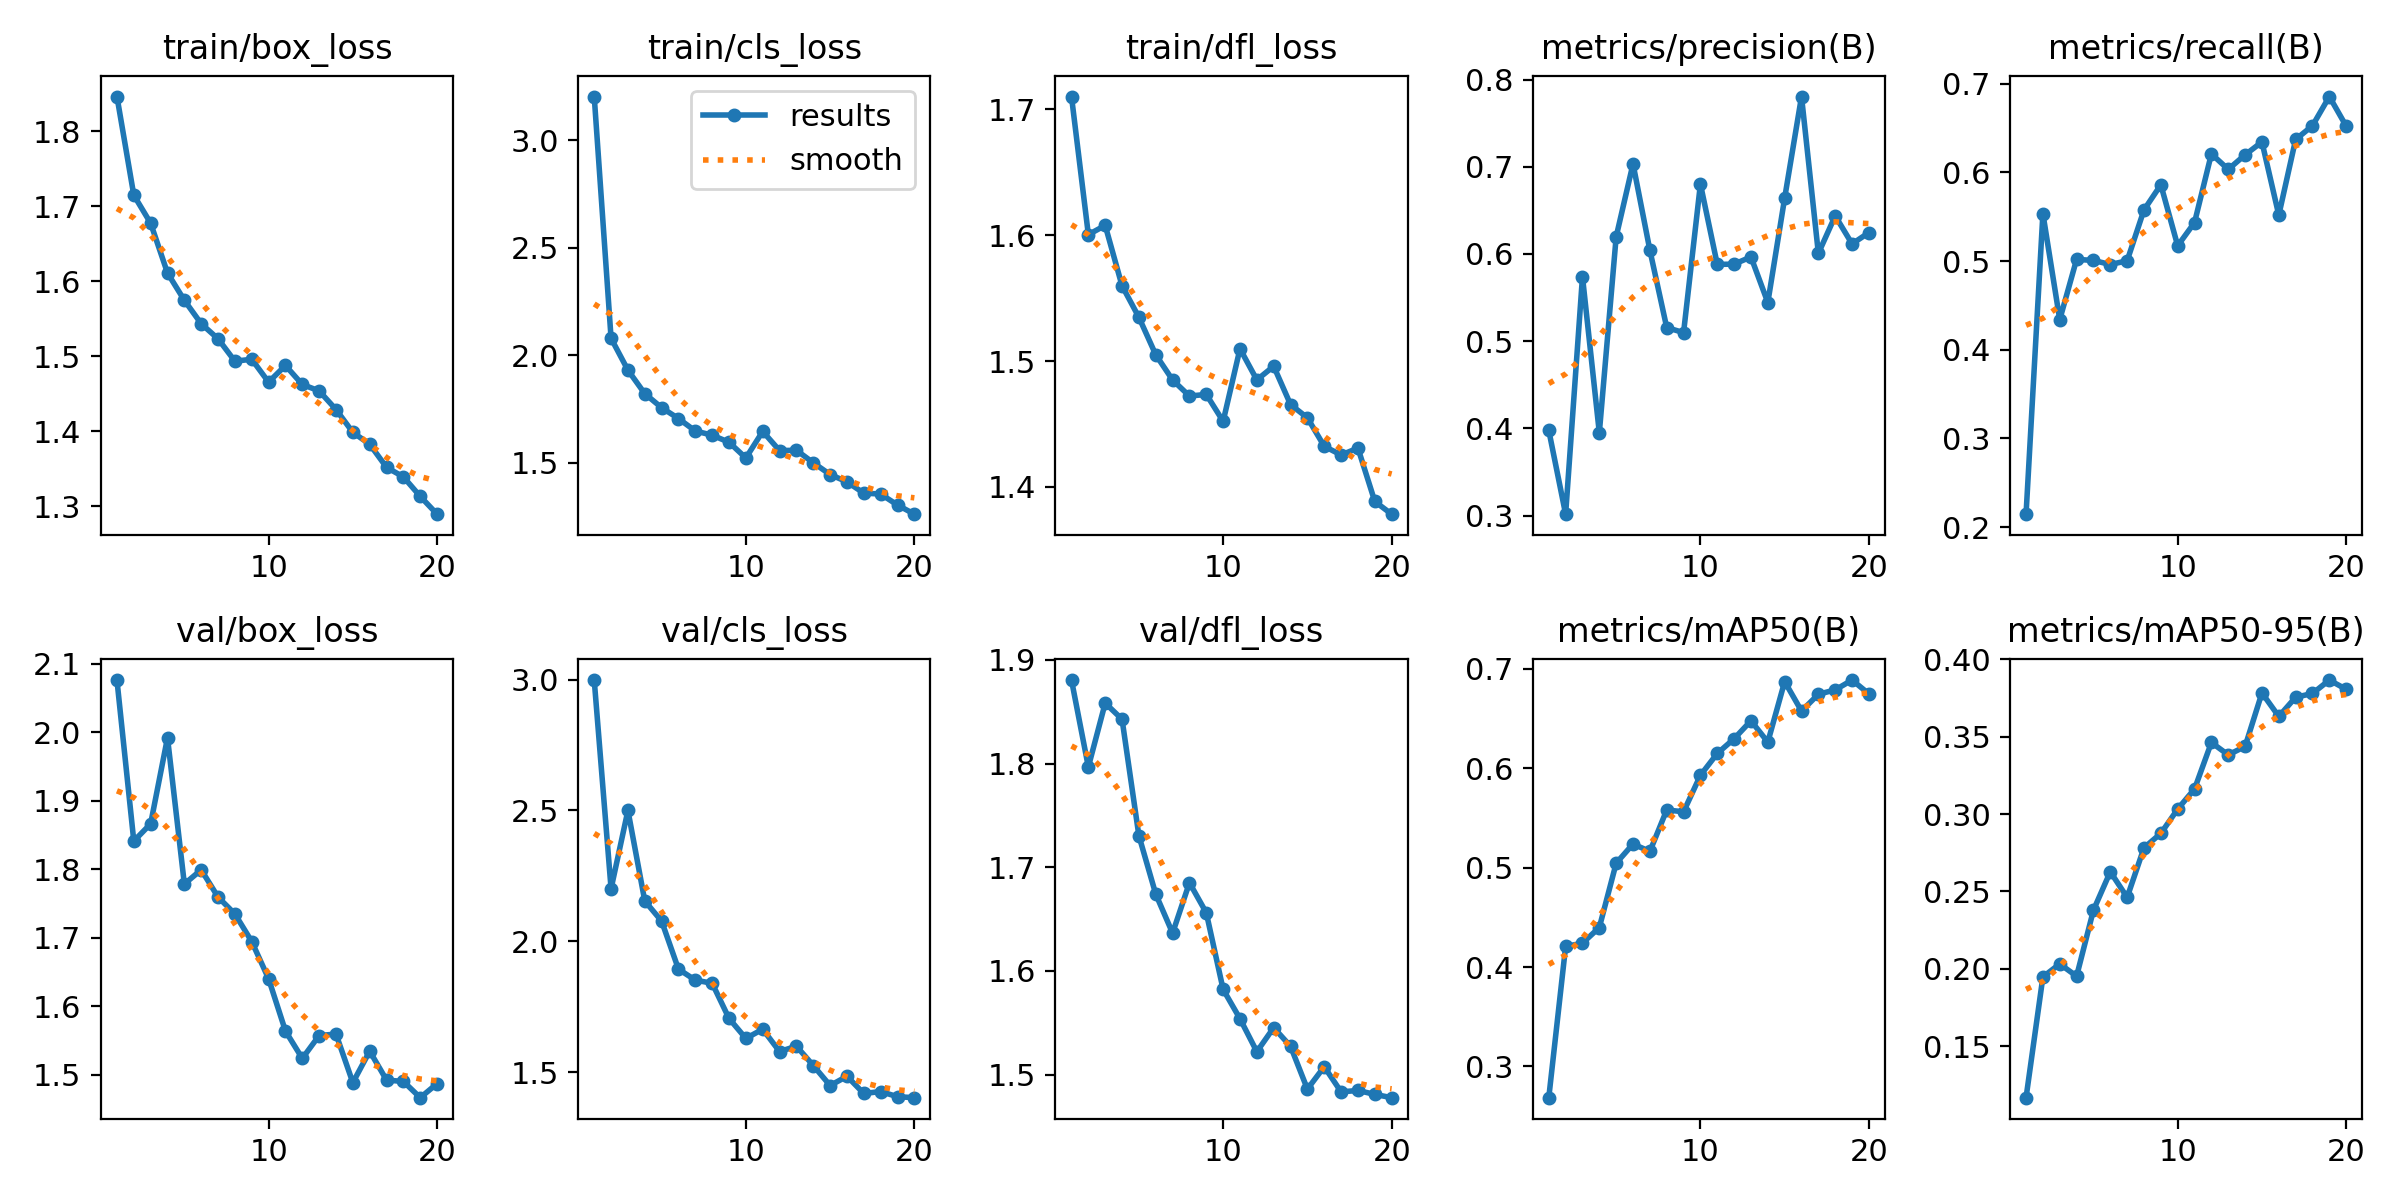

In [43]:
from IPython.display import Image as DisplayImage
if (RUN_DIR/'results.png').exists(): display(DisplayImage(filename=str(RUN_DIR/'results.png')))


### 7. confidence 비교

검증 이미지의 예측을 모은 뒤 confidence 0.15, 0.25, 0.50 이상인 박스만 남겨 성능을 비교한다.
정답과 예측의 클래스가 같고 IoU가 0.5 이상이면 맞힌 박스로 센다.
하나의 정답을 여러 예측이 중복해서 맞힌 것으로 세지 않도록 confidence가 높은 박스부터 비교한다.

- TP: 정답과 연결된 예측 박스
- FP: 정답과 연결되지 않은 예측 박스
- FN: 예측이 찾지 못한 정답 박스

Precision = TP / (TP + FP), Recall = TP / (TP + FN)이다.
F2 = 5PR / (4P + R)이며, Precision보다 Recall에 더 큰 비중을 준다.
이번 비교에서는 결함을 놓치는 경우를 줄이는 데 비중을 두고 검증 F2가 가장 높은 기준을 선택했다.
동점이면 FP가 적은 값, 그래도 같으면 더 높은 confidence를 사용한다.

NMS IoU는 0.7로 고정했다. NMS는 겹치는 예측 박스를 정리하는 과정이고,
위의 IoU 0.5는 예측이 정답과 맞는지 평가하는 기준이다.


In [44]:
def pair_iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1]); x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    union=(a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/union if union>0 else 0.
def match_detections(gt,pred,threshold):
    # 예측 한 개의 구조: [클래스, x1, y1, x2, y2, confidence]
    pred=sorted([p for p in pred if p[5]>=threshold],key=lambda p:-p[5])
    used=set(); tp=0
    for p in pred:
        candidates=[(pair_iou(p[1:5],g[1:5]),j) for j,g in enumerate(gt) if j not in used and int(p[0])==int(g[0])]
        overlap,j=max(candidates,default=(0.,-1))
        if overlap>=.5: used.add(j); tp+=1
    return tp,len(pred)-tp,len(gt)-tp
def collect_predictions(subset):
    predictions={}
    for result in best_model.predict(source=[r['yolo_image'] for r in subset],stream=True,
                                      imgsz=IMGSZ,conf=.001,iou=.7,device=0,verbose=False):
        raw=result.boxes.data.cpu().numpy().tolist()
        predictions[Path(result.path).stem]=[[int(b[5]),*map(float,b[:4]),float(b[4])] for b in raw]
    assert len(predictions)==len(subset)
    return predictions
def measure(subset,predictions,threshold):
    rows=[]
    for r in subset:
        tp,fp,fn=match_detections(r['boxes'],predictions[r['id']],threshold)
        rows.append({'id':r['id'],'image_type':NAMES[r['stratum_id']],'TP':tp,'FP':fp,'FN':fn})
    table=pd.DataFrame(rows); tp,fp,fn=table[['TP','FP','FN']].sum().tolist()
    p=tp/(tp+fp) if tp+fp else 0.; rec=tp/(tp+fn) if tp+fn else 0.
    f2=5*p*rec/(4*p+rec) if 4*p+rec else 0.
    return {'confidence':threshold,'TP':int(tp),'FP':int(fp),'FN':int(fn),'precision':p,'recall':rec,'F2':f2},table
val_records=sorted([r for r in records if r['split']=='val'],key=lambda r:r['id'])
val_predictions=collect_predictions(val_records)
threshold_table=pd.DataFrame([measure(val_records,val_predictions,t)[0] for t in [.15,.25,.50]])
chosen=threshold_table.sort_values(['F2','FP','confidence'],ascending=[False,True,False]).iloc[0]
CHOSEN_CONF=float(chosen['confidence'])
threshold_table.to_csv(ART/'validation_thresholds.csv',index=False)
(ART/'validation_predictions.json').write_text(json.dumps(val_predictions))
display(threshold_table.round(4)); print('Validation-selected confidence:',CHOSEN_CONF)


,confidence,TP,FP,FN,precision,recall,F2
0,0.15,493,429,172,0.5347,0.7414,0.6882
1,0.25,436,229,229,0.6556,0.6556,0.6556
2,0.50,339,67,326,0.8350,0.5098,0.5528


Validation-selected confidence: 0.15


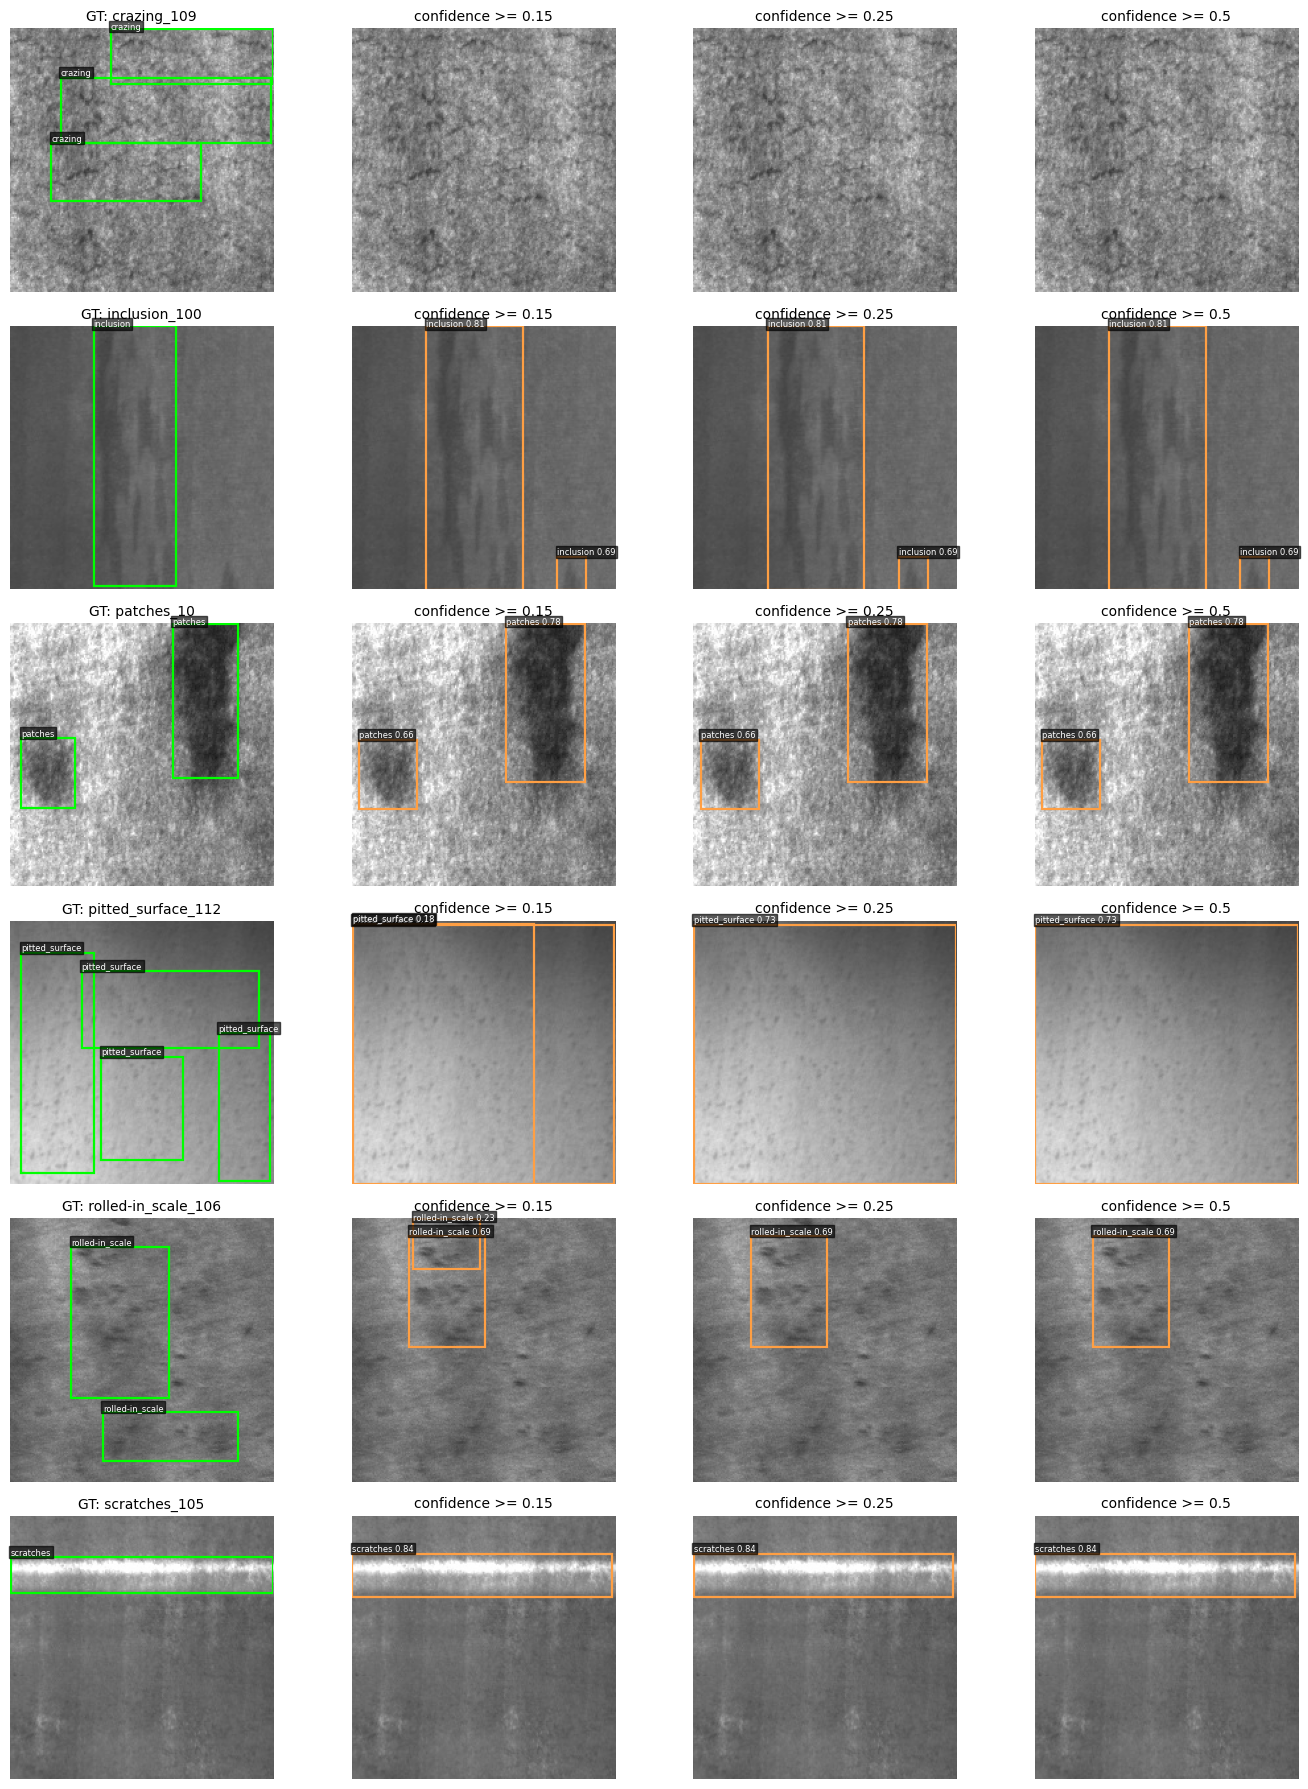

In [45]:
val_samples=[next(r for r in val_records if r['stratum_id']==c) for c in range(6)]
fig,axes=plt.subplots(6,4,figsize=(14,18))
for row,r in enumerate(val_samples):
    draw_boxes(axes[row,0],r['yolo_image'],r['boxes'],f'GT: {r["id"]}')
    for col,t in enumerate([.15,.25,.50],1):
        pred=[p for p in val_predictions[r['id']] if p[5]>=t]
        draw_boxes(axes[row,col],r['yolo_image'],[p[:5] for p in pred],f'confidence >= {t}',color='#ff9f43',scores=[p[5] for p in pred])
plt.tight_layout(); fig.savefig(ART/'confidence_comparison.png',dpi=140); plt.show()


### 8. 시험 데이터 평가

검증 데이터에서 선택한 confidence를 시험 데이터에도 그대로 적용했다.
mAP50과 mAP50–95는 Ultralytics로 계산하고, 선택한 confidence의 TP·FP·FN과
Precision·Recall·F2는 별도로 계산했다.

mAP 계산에는 낮은 점수의 예측도 필요해 `conf=0.001`을 사용했다.
이때 저장된 자동 혼동행렬과 confidence 0.15의 TP·FP·FN 표는 평가 조건이 다르다.
또한 Ultralytics 로그의 P/R은 자체적으로 선택한 지점의 값이므로 아래 고정 confidence 표와 구분한다.


In [46]:
test_metrics=best_model.val(data=str(DATA_YAML),split='test',imgsz=IMGSZ,batch=BATCH,
                          device=0,conf=.001,iou=.7,plots=True,project=str(BASE/'evaluations'),
                          name='test',exist_ok=True,verbose=False)
ap50=np.asarray(test_metrics.box.ap50)
ap=np.asarray(test_metrics.box.ap)
ap_indices=np.asarray(test_metrics.box.ap_class_index,dtype=int)
class_ap=pd.DataFrame({'class':[NAMES[c] for c in ap_indices], 'AP50':ap50, 'AP50-95':ap})
class_ap.to_csv(ART/'test_class_ap.csv',index=False)
test_records=sorted([r for r in records if r['split']=='test'],key=lambda r:r['id'])
test_predictions=collect_predictions(test_records)
operating_metrics,test_errors=measure(test_records,test_predictions,CHOSEN_CONF)
summary={'test_mAP50':float(test_metrics.box.map50),'test_mAP50_95':float(test_metrics.box.map),
         'operating_point':operating_metrics,'images':len(test_records),'gpu':env['gpu'],
         'actual_epochs':len(training_history),'selected_on':'validation','matching_iou':.5,'nms_iou':.7}
(ART/'test_summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False))
(ART/'test_predictions.json').write_text(json.dumps(test_predictions))
test_errors.to_csv(ART/'test_per_image.csv',index=False)
display(pd.DataFrame([{'mAP50':summary['test_mAP50'],'mAP50-95':summary['test_mAP50_95']}]).round(4))
display(class_ap.round(4)); display(pd.DataFrame([operating_metrics]).round(4))


Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 511.3±317.6 MB/s, size: 14.7 KB)
val: Scanning /content/steel_defect_project/dataset/split_0743b20802d2/labels/test... 271 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 271/271 1.9Kit/s 0.1s<0.1s
val: New cache created: /content/steel_defect_project/dataset/split_0743b20802d2/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 5.4it/s 3.2s<0.1s
                   all        271        621      0.625       0.73      0.727      0.414
Speed: 1.2ms preprocess, 2.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/steel_defect_project/evaluations/test


,mAP50,mAP50-95
0,0.7274,0.4137


,class,AP50,AP50-95
0,crazing,0.4188,0.1634
1,inclusion,0.8033,0.4406
2,patches,0.9294,0.5907
3,pitted_surface,0.7491,0.5003
4,rolled-in_scale,0.5108,0.2454
5,scratches,0.9530,0.5419


,confidence,TP,FP,FN,precision,recall,F2
0,0.15,482,426,139,0.5308,0.7762,0.7105


### 9. 성공·실패 사례

시험 데이터에서 모두 맞힌 사례, 많이 놓친 사례, 오검출이 많은 사례를 최대 3장씩 골랐다.
왼쪽은 정답 박스, 오른쪽은 선택한 confidence에서의 예측이다.
특징을 살펴보기 위해 고른 이미지이므로 이 그림만으로 전체 오류율을 판단하지는 않는다.


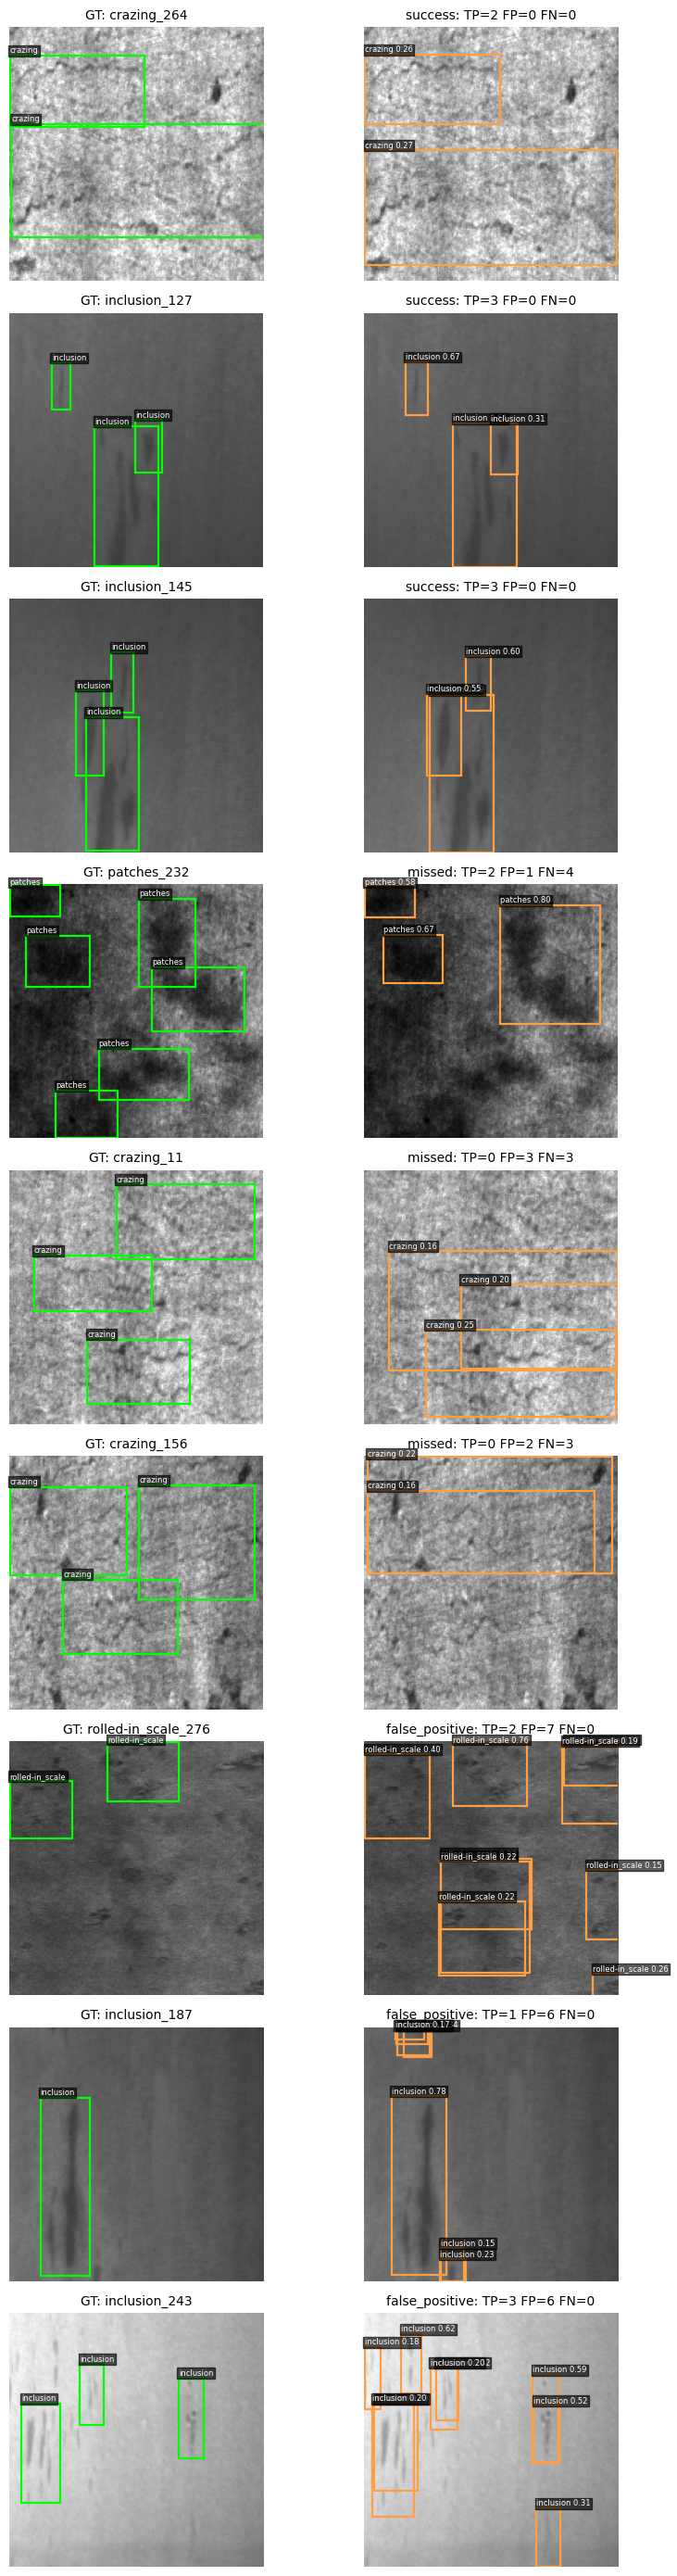

Grouped by filename image type; mixed-class images retain all annotated defects.


,TP,FP,FN
image_type,,,
crazing,45,59,56
inclusion,112,94,14
patches,117,66,7
pitted_surface,51,37,23
rolled-in_scale,72,112,30
scratches,85,58,9


In [47]:
record_by_id={r['id']:r for r in records}
selected=[]; used=set()
groups=[('success',test_errors.query('FN == 0 and FP == 0').sort_values('id')),
        ('missed',test_errors.query('FN > 0').sort_values(['FN','id'],ascending=[False,True])),
        ('false_positive',test_errors.query('FP > 0').sort_values(['FP','id'],ascending=[False,True]))]
for kind,frame in groups:
    count=0
    for _,row in frame.iterrows():
        if row['id'] in used: continue
        selected.append((kind,row)); used.add(row['id']); count+=1
        if count==3: break
if selected:
    fig,axes=plt.subplots(len(selected),2,figsize=(9,3.1*len(selected)),squeeze=False)
    for i,(kind,row) in enumerate(selected):
        r=record_by_id[row['id']]
        pred=[p for p in test_predictions[r['id']] if p[5]>=CHOSEN_CONF]
        draw_boxes(axes[i,0],r['yolo_image'],r['boxes'],f'GT: {r["id"]}')
        draw_boxes(axes[i,1],r['yolo_image'],[p[:5] for p in pred],
                   f'{kind}: TP={row.TP} FP={row.FP} FN={row.FN}',color='#ff9f43',scores=[p[5] for p in pred])
    plt.tight_layout(); fig.savefig(ART/'error_examples.png',dpi=140); plt.show()
print('Grouped by filename image type; mixed-class images retain all annotated defects.')
display(test_errors.groupby('image_type')[['TP','FP','FN']].sum())


### 10. 결과 해석

학습이 진행되면서 학습·검증 손실은 대체로 감소했고 검증 mAP는 올라갔다.
시험 mAP50은 0.7274였지만 클래스마다 차이가 있었다.
AP50–95는 patches에서 가장 높았고 crazing에서 가장 낮았다.

이미지를 보면 다음과 같은 오류가 있었다.

- `crazing_11`: 균열 부근에 예측은 있었지만 정답 박스와 충분히 겹치지 않았다. TP=0, FP=3, FN=3이었다.
- `patches_232`: 여러 정답 영역을 큰 예측 박스로 묶는 모습이 보였다. TP=2, FP=1, FN=4였다.
- `rolled-in_scale_276`: 정답 2개를 찾았지만 추가로 7개의 박스를 예측했다.

따라서 결함 부근에 박스가 표시되는 것만으로 정확하게 탐지했다고 보기 어려웠다.
위치와 크기가 정답에 얼마나 가까운지도 확인할 필요가 있다.

confidence 0.15는 비교한 세 값 중 검증 F2가 가장 높았다.
시험 Recall은 0.7762였지만 Precision은 0.5308이어서, 놓치는 결함을 줄이는 대신 오검출이 많았다.
이 기준이 실제 공장에서도 적절한지는 별도로 확인해야 한다.

이번 실험에는 정상 제품, 새로운 종류의 결함, 다른 촬영 환경의 데이터가 포함되지 않았다.
또한 같은 seed로 한 번 학습한 결과이므로 여러 번 실행했을 때의 성능 차이는 확인하지 못했다.


In [48]:
best_class=class_ap.sort_values('AP50-95',ascending=False).iloc[0]
worst_class=class_ap.sort_values('AP50-95').iloc[0]
report=f"""### 실제 실행 결과
- GPU: **{env['gpu']}**, 실제 학습: **{len(training_history)} epochs**, 입력: **{IMGSZ}**.
- 시험 이미지: **{len(test_records)}장**, mAP50: **{summary['test_mAP50']:.4f}**, mAP50–95: **{summary['test_mAP50_95']:.4f}**.
- AP50–95 최고 클래스: **{best_class['class']} ({best_class['AP50-95']:.4f})**.
- AP50–95 최저 클래스: **{worst_class['class']} ({worst_class['AP50-95']:.4f})**.
- 검증 F2로 선택한 confidence: **{CHOSEN_CONF:.2f}**.
- 해당 임계값의 시험 Precision: **{operating_metrics['precision']:.4f}**, Recall: **{operating_metrics['recall']:.4f}**, F2: **{operating_metrics['F2']:.4f}**.
- 시험 박스 기준: TP **{operating_metrics['TP']}**, FP **{operating_metrics['FP']}**, FN **{operating_metrics['FN']}**.

### 해석 범위
위 결과는 기존 여섯 결함 유형의 객체 탐지 성능이다. 정상 제품 오판정률과 미지 결함 검출률은 평가하지 않았다.
클래스별 차이의 원인은 실패 사례에서 추가 확인해야 하며, 수치만으로 원인을 단정하지 않는다.
"""
display(Markdown(report))
_ = (ART/'measured_summary.md').write_text(report,encoding='utf-8')


### 실제 실행 결과
- GPU: **Tesla T4**, 실제 학습: **20 epochs**, 입력: **320**.
- 시험 이미지: **271장**, mAP50: **0.7274**, mAP50–95: **0.4137**.
- AP50–95 최고 클래스: **patches (0.5907)**.
- AP50–95 최저 클래스: **crazing (0.1634)**.
- 검증 F2로 선택한 confidence: **0.15**.
- 해당 임계값의 시험 Precision: **0.5308**, Recall: **0.7762**, F2: **0.7105**.
- 시험 박스 기준: TP **482**, FP **426**, FN **139**.

### 해석 범위
위 결과는 기존 여섯 결함 유형의 객체 탐지 성능이다. 정상 제품 오판정률과 미지 결함 검출률은 평가하지 않았다.
클래스별 차이의 원인은 실패 사례에서 추가 확인해야 하며, 수치만으로 원인을 단정하지 않는다.


### 11. KPT 회고

| 항목 | 내용 |
|---|---|
| Keep | confidence별로 미검출과 오검출을 함께 비교하는 방식을 유지하고 싶다. 한 가지 기준의 결과만 보는 것보다 검출률과 오검출의 관계를 확인하기 좋았다. |
| Problem | 낮은 confidence에서는 오검출이 많았다. 결함을 많이 찾았다는 이유만으로 성능이 충분하다고 판단하기 어려웠다. |
| Try | 같은 조건에서 입력 크기만 320에서 640으로 바꿔 성능과 학습 시간을 비교해 보고 싶다. |
| 다음 실험 | 데이터 분할, seed 42, 20 epochs, YOLOv8n은 유지한다. 검증 데이터의 crazing AP50–95, F2, 학습 시간을 표로 비교한다. 성능이 나아지지 않더라도 그 결과를 기록한다. |

입력 크기 640 실험은 다음에 진행할 계획이다.
원본이 200×200이므로 이미지를 크게 넣는 것만으로 세부 정보가 늘어나는 것은 아니라는 점도 살펴보려 한다.


### 12. 결과 파일 저장

다음 셀은 결과 표, 예측 이미지, 학습 설정과 가중치를 ZIP으로 묶는다.
Colab 세션이 끝나기 전에 ZIP을 내려받고 노트북도 출력과 함께 저장한다.

- `artifacts/`: 데이터 분할, 평가 수치, 예측 결과, 비교 그림
- `runs/`: 학습 기록과 가중치
- `evaluations/test/`: 시험 평가에서 생성된 그래프

저장된 예측의 지표를 다시 계산하는 코드는 `evaluate_saved.py`에 정리했다.


In [49]:
# 결과와 가중치를 ZIP으로 저장한다.
bundle=BASE/'steel_defect_results.zip'
with zipfile.ZipFile(bundle,'w',zipfile.ZIP_DEFLATED) as z:
    for folder in [ART,RUN_DIR,BASE/'evaluations']:
        if folder.exists():
            for p in folder.rglob('*'):
                if p.is_file(): z.write(p,p.relative_to(BASE))
    z.write(DATA_YAML,'dataset/data.yaml')
print('Result bundle:',bundle, 'MB:',round(bundle.stat().st_size/1e6,2))
print('VS Code에서 Ctrl+S로 노트북 결과를 저장하세요.')
print('Colab 파일 패널에서 steel_defect_results.zip을 다운로드하면 가중치와 표를 보존할 수 있습니다.')


Result bundle: /content/steel_defect_project/steel_defect_results.zip MB: 24.43
VS Code에서 Ctrl+S로 노트북 결과를 저장하세요.
Colab 파일 패널에서 steel_defect_results.zip을 다운로드하면 가중치와 표를 보존할 수 있습니다.
